In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

results = {}
models = {
    "Logistic Regression" : LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        class_weight="balanced"
    ),
    "SVM": SVC(
        random_state=42,
        class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    )

}   
for name, model in models.items():
    if isinstance(model, SVC):
        model = CalibratedClassifierCV(estimator=model, cv=5, ensemble=False)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, -1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    print(f"--  {name} ---")
    print(classification_report(y_test, y_pred))
    results[name] = {
        "precision": precision,
        "recall": recall,
        "f1 score": f1,
        "ROC-AUC": roc_auc,
        'cm': cm
    }

results_df = pd.DataFrame(results).T
print(results_df.round(4))

--  Logistic Regression ---
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

--  Decision Tree ---
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1035
           1       0.49      0.50      0.49       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409

--  Random Forest ---
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1035
           1       0.54      0.62      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
we

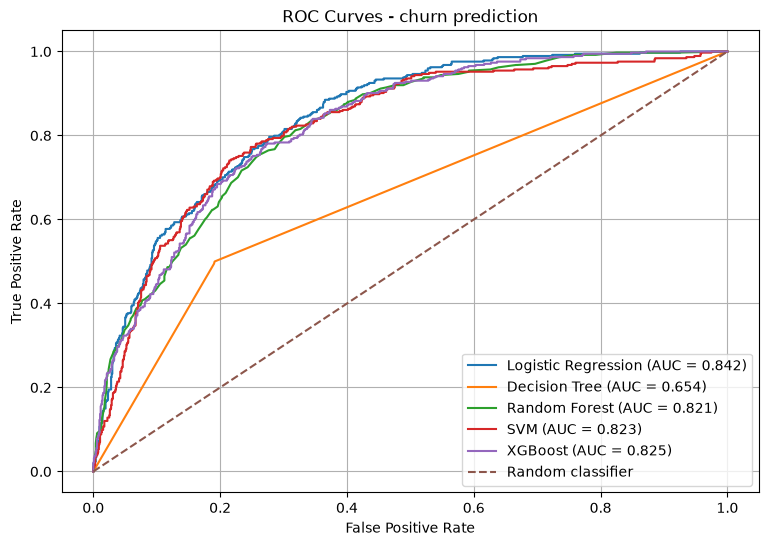

In [19]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

for name, model in models.items():
    if isinstance(model, SVC):
        model = CalibratedClassifierCV(estimator=model, cv=5, ensemble=False)
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(
        fpr, 
        tpr, 
        label=f"{name} (AUC = {auc:.3f})"
    )
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - churn prediction")
plt.legend()
plt.grid()
plt.show()

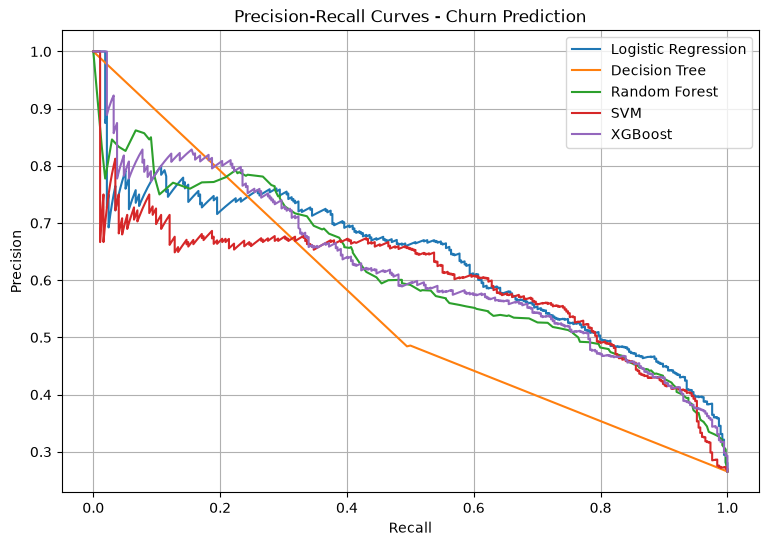

In [20]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(9, 6))
for name, model in models.items():
    if isinstance(model, SVC):
        model = CalibratedClassifierCV(estimator=model, cv=5, ensemble=False)
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(
        y_test, 
        y_proba
    )
    plt.plot(
        recall,
        precision,
        label=name
    )
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - Churn Prediction")
plt.legend()
plt.grid()
plt.show()

In [ ]:
top_models = [
    "Logistic Regression",
    "SVM",
    "XGBoost"
]